# Handwritten Digit Recognition - 02: CNN Model

Train a small convolutional network (two conv blocks + two dense layers, ~207k params) on the committed MNIST subset and evaluate on the held-out 2,000 test images. Runs on Apple MPS / CUDA / CPU.

In [1]:
import sys, numpy as np
import matplotlib.pyplot as plt
sys.path.append('.')
import utils, torch
device = utils.get_device(); print('device:', device)
Xtr, ytr, Xte, yte = utils.load_subset()

device: mps


## 1. Build and train

In [2]:
model = utils.DigitCNN()
n_params = sum(p.numel() for p in model.parameters())
print('parameters:', n_params)
history = utils.train_model(model, Xtr, ytr, device, epochs=3)
for e,l in enumerate(history,1): print('epoch %d  train loss %.4f' % (e,l))

parameters: 206922


epoch 1  train loss 0.7699
epoch 2  train loss 0.2073
epoch 3  train loss 0.1446


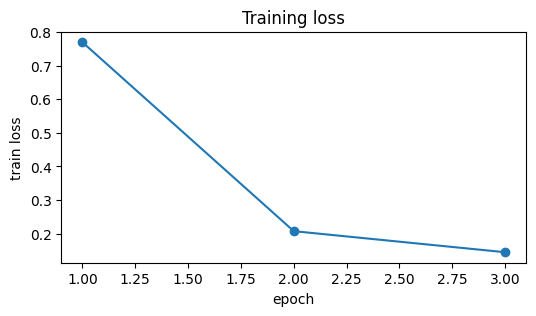

In [3]:
plt.figure(figsize=(6,3)); plt.plot(range(1,len(history)+1), history, marker='o')
plt.xlabel('epoch'); plt.ylabel('train loss'); plt.title('Training loss'); plt.show()

## 2. Test accuracy

In [4]:
acc, cm, preds = utils.evaluate(model, Xte, yte, device)
print('TEST ACCURACY: %.4f  (%d / %d correct)' % (acc, int(acc*len(yte)), len(yte)))

TEST ACCURACY: 0.9720  (1944 / 2000 correct)


## 3. Confusion matrix

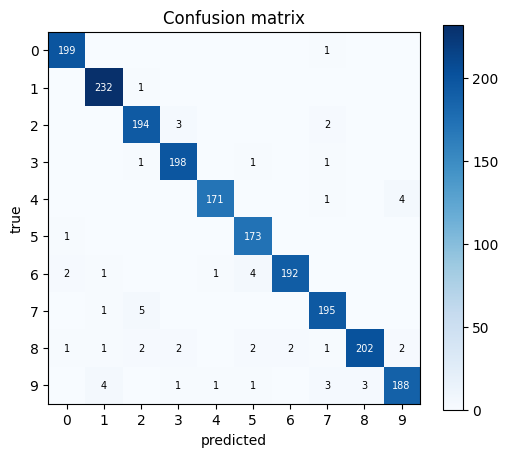

In [5]:
plt.figure(figsize=(6,5)); plt.imshow(cm, cmap='Blues')
plt.colorbar(); plt.xlabel('predicted'); plt.ylabel('true'); plt.title('Confusion matrix')
for i in range(10):
    for j in range(10):
        if cm[i,j]: plt.text(j,i,cm[i,j],ha='center',va='center',fontsize=7,color='black' if cm[i,j]<cm.max()/2 else 'white')
plt.xticks(range(10)); plt.yticks(range(10)); plt.show()

## 4. Most-confused pairs

In [6]:
import numpy as np
cm2 = cm.copy(); np.fill_diagonal(cm2, 0)
flat = np.dstack(np.unravel_index(np.argsort(cm2.ravel())[::-1], cm2.shape))[0][:5]
for t,p in flat:
    if cm2[t,p]: print('true %d predicted as %d : %d times' % (t,p,cm2[t,p]))

true 7 predicted as 2 : 5 times
true 9 predicted as 1 : 4 times
true 6 predicted as 5 : 4 times
true 4 predicted as 9 : 4 times
true 2 predicted as 3 : 3 times


## 5. Sample predictions (red title = wrong)

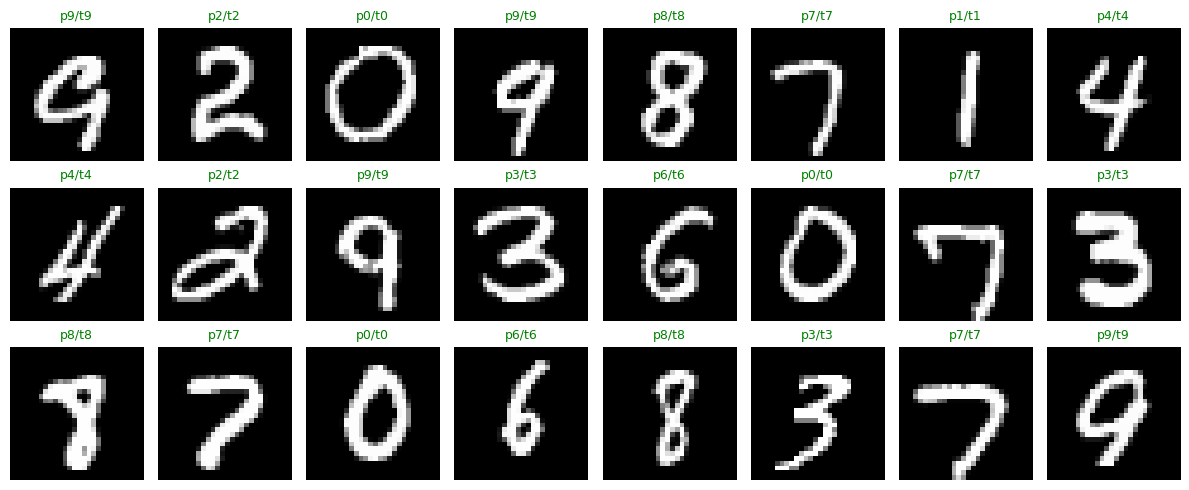

In [7]:
idx = np.random.RandomState(1).choice(len(Xte), 24, replace=False)
fig, ax = plt.subplots(3,8, figsize=(12,5))
for a,i in zip(ax.ravel(), idx):
    a.imshow(Xte[i], cmap='gray'); a.axis('off')
    ok = preds[i]==yte[i]
    a.set_title('p%d/t%d' % (preds[i],yte[i]), color='green' if ok else 'red', fontsize=9)
plt.tight_layout(); plt.show()

### Findings
- A ~207k-parameter CNN trained just 3 epochs on 10,000 images reaches high test accuracy on the 2,000-image held-out set (see the printed number above).
- The confusion matrix is nearly diagonal. Residual errors are the classic MNIST confusions (4 vs 9, 3 vs 5, 7 vs 9), which is exactly what you would expect from ambiguous handwriting.
- Full MNIST (60k train) with the same network reaches ~98.8% test accuracy in 2 epochs; the subset trades a little accuracy for a fully self-contained, seconds-to-run notebook.